# THRESHOLD VALIDATION WITH THE FINAL DATA VALIDATION TO CHOOSE THE BETTER THRESHOLD for the similarity models

C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


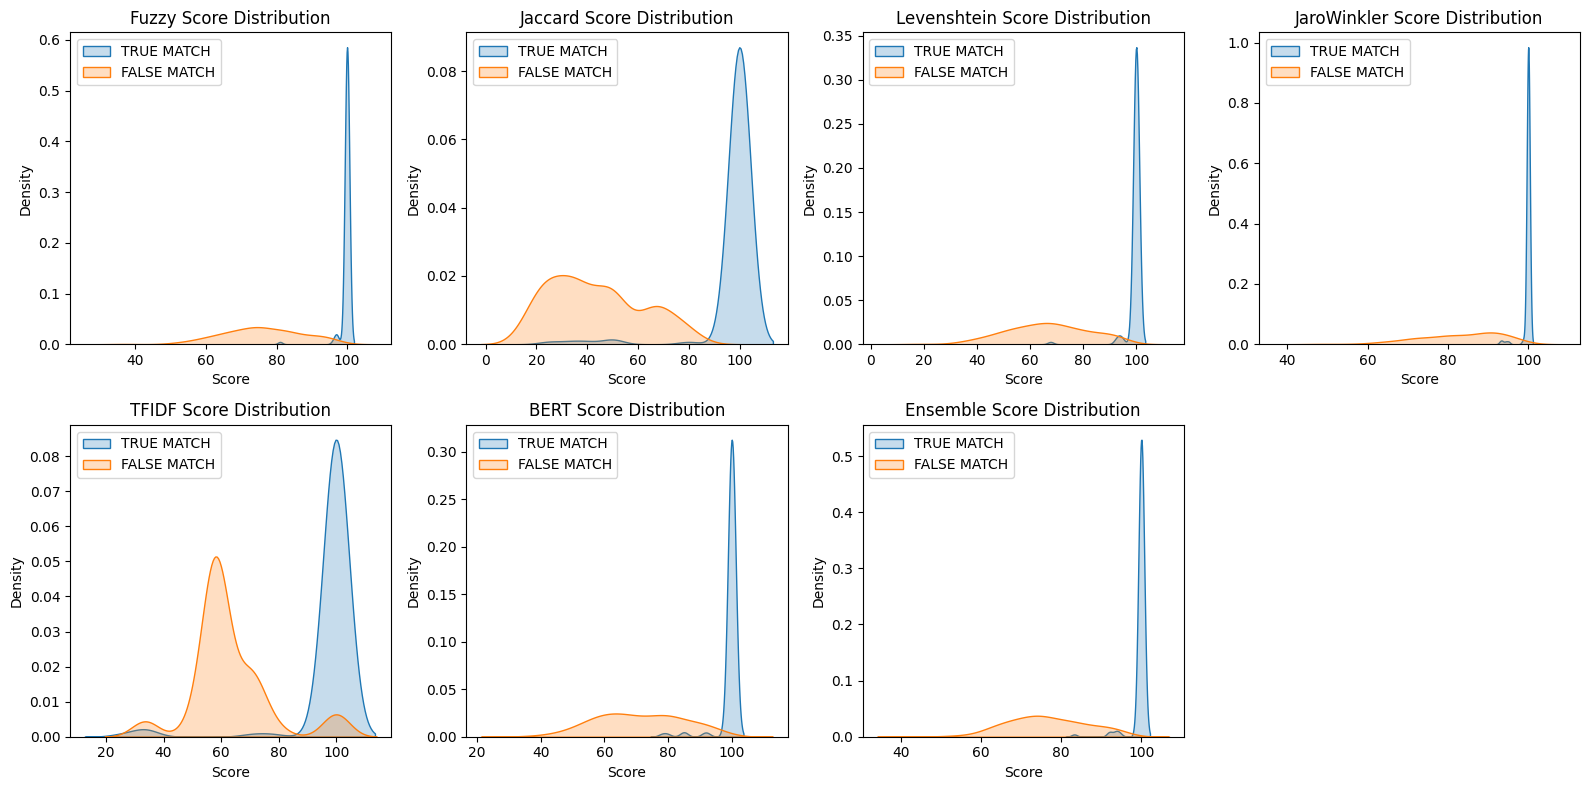

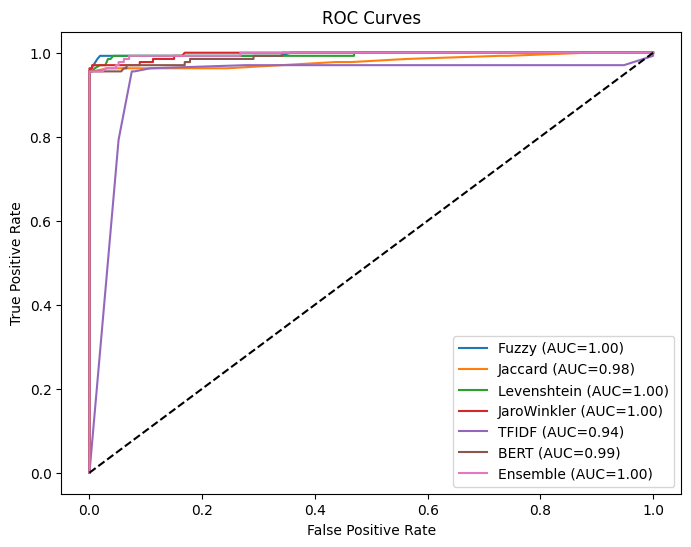

Optimal thresholds based on Youden's Index and F1 maximization:

Model: Fuzzy
  - Optimal Threshold (Youden): 96.000
  - Best F1 Threshold: 96.000
  - Max F1 Score: 0.982

Model: Jaccard
  - Optimal Threshold (Youden): 100.000
  - Best F1 Threshold: 100.000
  - Max F1 Score: 0.977

Model: Levenshtein
  - Optimal Threshold (Youden): 100.000
  - Best F1 Threshold: 100.000
  - Max F1 Score: 0.977

Model: JaroWinkler
  - Optimal Threshold (Youden): 98.667
  - Best F1 Threshold: 98.667
  - Max F1 Score: 0.981

Model: TFIDF
  - Optimal Threshold (Youden): 100.000
  - Best F1 Threshold: 100.000
  - Max F1 Score: 0.921

Model: BERT
  - Optimal Threshold (Youden): 100.000
  - Best F1 Threshold: 100.000
  - Max F1 Score: 0.977

Model: Ensemble
  - Optimal Threshold (Youden): 100.000
  - Best F1 Threshold: 100.000
  - Max F1 Score: 0.977


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from fuzzywuzzy import fuzz
from Levenshtein import distance as levenshtein_distance, jaro_winkler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
import os
from datetime import datetime
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, f1_score

# -----------------------------
# Helper function: Normalize name
# -----------------------------
def normalize_name(name):
    """Normalize name for comparison"""
    if pd.isna(name):
        return ""
    return str(name).lower().strip()


# -----------------------------
# Individual similarity functions - ALL RETURN 0-100 SCALE
# -----------------------------
def fuzzy_similarity(name1, name2):
    """Return fuzzy similarity score (0-100)"""
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    return fuzz.ratio(n1, n2)  # Already 0-100

def levenshtein_similarity(name1, name2):
    """Return Levenshtein similarity score (0-100)"""
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    distance = levenshtein_distance(n1, n2)
    max_len = max(len(n1), len(n2))
    
    if max_len == 0:
        return 0.0
    
    # Convert 0-1 to 0-100
    return (1 - (distance / max_len)) * 100

def jaccard_similarity(name1, name2):
    """Return Jaccard similarity score (0-100)"""
    n1 = set(normalize_name(name1).split())
    n2 = set(normalize_name(name2).split())
    
    if not n1 or not n2:
        return 0.0
    
    # Convert 0-1 to 0-100
    return (len(n1.intersection(n2)) / len(n1.union(n2))) * 100

def jaro_winkler_similarity(name1, name2):
    """Return Jaro-Winkler similarity score (0-100)"""
    n1, n2 = normalize_name(name1), normalize_name(name2)
    # Convert 0-1 to 0-100
    return jaro_winkler(n1, n2) * 100

def tfidf_cosine_similarity(name1, name2):
    """Return TF-IDF cosine similarity score (0-100)"""
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    tfidf = TfidfVectorizer().fit([n1, n2])
    vectors = tfidf.transform([n1, n2])
    
    score = cosine_similarity(vectors[0], vectors[1])[0][0]
    # Convert 0-1 to 0-100
    return score * 100

# Initialize BERT model
try:
    bert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    BERT_AVAILABLE = True
except Exception as e:
    print(f"⚠️ BERT model not available: {e}")
    print("⚠️ Continuing without BERT similarity...")
    BERT_AVAILABLE = False

def bert_similarity(name1, name2):
    """Return BERT cosine similarity score (0-100)"""
    if not BERT_AVAILABLE:
        return 0.0
    
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    embeddings = bert_model.encode([n1, n2])
    similarity = np.dot(embeddings[0], embeddings[1]) / (
        np.linalg.norm(embeddings[0]) * np.linalg.norm(embeddings[1])
    )
    
    # Convert 0-1 to 0-100
    return float(similarity) * 100

# -----------------------------
# Ensemble scoring - ALL INPUTS ARE 0-100
# -----------------------------
def ensemble_score(fz, jc, lev, jw, tfidf, bert):
    """Calculate weighted ensemble score (0-100)"""
    # All inputs are already 0-100 scale
    return round(
        (fz * 0.70) +
        (jw * 0.20) +
        ((tfidf+bert)/2) * 0.10,2
    )

# Load your labeled validation dataset
df_val = pd.read_excel("C:\\Users\\USER\\Desktop\\Data cleaning (NLP)\\Output\\FUZZY_ALO_MODELS\\FINAL_EVALUATION_DATA.xlsx")  #update this path
df_val 

# Ensure your columns are correctly named
# Example: 'E NAME1', 'E NAME2', 'E NO1', 'E NO2', 'Label'

# Initialize lists to store scores
fz_scores = []
jc_scores = []
lev_scores = []
jw_scores = []
tfidf_scores = []
bert_scores = []
ensemble_scores = []
true_labels = []

# Loop through pairs to compute scores
for idx, row in df_val.iterrows():
    name1 = row['NAME1']
    name2 = row['NAME2']
    label = row['LABEL']
    # Compute scores
    fz = fuzzy_similarity(name1, name2)
    jc = jaccard_similarity(name1, name2)
    lev = levenshtein_similarity(name1, name2)
    jw = jaro_winkler_similarity(name1, name2)
    tfidf = tfidf_cosine_similarity(name1, name2)
    bert = bert_similarity(name1, name2)
    ens = ensemble_score(fz, jc, lev, jw, tfidf, bert)

    # Append to lists
    fz_scores.append(fz)
    jc_scores.append(jc)
    lev_scores.append(lev)
    jw_scores.append(jw)
    tfidf_scores.append(tfidf)
    bert_scores.append(bert)
    ensemble_scores.append(ens)
    true_labels.append(label)

# Convert to numpy arrays for analysis
scores_dict = {
    'Fuzzy': np.array(fz_scores),
    'Jaccard': np.array(jc_scores),
    'Levenshtein': np.array(lev_scores),
    'JaroWinkler': np.array(jw_scores),
    'TFIDF': np.array(tfidf_scores),
    'BERT': np.array(bert_scores),
    'Ensemble': np.array(ensemble_scores)
}

# Function to find optimal threshold using Youden's Index
def find_best_threshold(scores, labels):
    fpr, tpr, thresholds = roc_curve(labels, scores)
    # Youden's index
    youden_idx = np.argmax(tpr - fpr)
    optimal_thresh = thresholds[youden_idx]
    # Also compute F1 at various thresholds
    f1_scores = []
    for thresh in thresholds:
        preds = (scores >= thresh).astype(int)
        f1 = f1_score(labels, preds)
        f1_scores.append(f1)
    max_f1_idx = np.argmax(f1_scores)
    best_f1_thresh = thresholds[max_f1_idx]
    return optimal_thresh, best_f1_thresh, f1_scores[max_f1_idx], fpr, tpr

# Analyze each model
results = {}
for model_name, scores in scores_dict.items():
    optimal_thresh, best_f1_thresh, max_f1, fpr, tpr = find_best_threshold(scores, true_labels)
    results[model_name] = {
        'Optimal Threshold (Youden)': optimal_thresh,
        'Best F1 Threshold': best_f1_thresh,
        'Max F1 Score': max_f1,
        'FPR': fpr,
        'TPR': tpr
    }

# Plot score distributions
plt.figure(figsize=(16, 8))
for i, (model_name, scores) in enumerate(scores_dict.items()):
    plt.subplot(2, 4, i+1)
    sns.kdeplot(scores[ np.array(true_labels)==1 ], label='TRUE MATCH', fill=True)
    sns.kdeplot(scores[ np.array(true_labels)==0 ], label='FALSE MATCH', fill=True)
    plt.title(f'{model_name} Score Distribution')
    plt.xlabel('Score')
    plt.legend()

plt.tight_layout()
plt.show()

# Plot ROC curves
plt.figure(figsize=(8,6))
for model_name, res in results.items():
    plt.plot(res['FPR'], res['TPR'], label=f"{model_name} (AUC={roc_auc_score(true_labels, scores_dict[model_name]):.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

# Output results
print("Optimal thresholds based on Youden's Index and F1 maximization:")
for model_name, res in results.items():
    print(f"\nModel: {model_name}")
    print(f"  - Optimal Threshold (Youden): {res['Optimal Threshold (Youden)']:.3f}")
    print(f"  - Best F1 Threshold: {res['Best F1 Threshold']:.3f}")
    print(f"  - Max F1 Score: {res['Max F1 Score']:.3f}")

# Save results to a CSV
thresholds_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Optimal Threshold (Youden)': [res['Optimal Threshold (Youden)'] for res in results.values()],
    'Best F1 Threshold': [res['Best F1 Threshold'] for res in results.values()],
    'Max F1 Score': [res['Max F1 Score'] for res in results.values()]
})
thresholds_df.to_csv('optimumthresholds_results.csv', index=False)

In [77]:
similarity_df.to_excel('Final_result.xlsx')

# ALL THE  NEW MERGED MIN_SCORE COMPUTED for all the similarity models for the Created FINAL VALIDATION DATA which already labelled


In [74]:
import pandas as pd
from fuzzywuzzy import fuzz
from Levenshtein import distance as levenshtein_distance, jaro_winkler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# -----------------------------
# Load labeled Excel
# -----------------------------
similarity_df = pd.read_excel(
    r"C:\Users\USER\Desktop\Data cleaning (NLP)\Output\FUZZY_ALO_MODELS\FINAL_EVALUATION_DATA.xlsx"
)

# -----------------------------
# Normalize text
# -----------------------------
def normalize(name):
    return str(name).lower().strip()

# -----------------------------
# Fuzzy, Levenshtein, Jaro-Winkler
# -----------------------------
similarity_df['fuzzy_score'] = similarity_df.apply(
    lambda row: fuzz.token_sort_ratio(normalize(row['NAME1']), normalize(row['NAME2'])), axis=1
)

similarity_df['levenshtein_score'] = similarity_df.apply(
    lambda row: (1 - levenshtein_distance(normalize(row['NAME1']), normalize(row['NAME2'])) /
                 max(len(normalize(row['NAME1'])), len(normalize(row['NAME2'])), 1)) * 100, axis=1
)

similarity_df['jaro_score'] = similarity_df.apply(
    lambda row: jaro_winkler(normalize(row['NAME1']), normalize(row['NAME2'])) * 100, axis=1
)

# -----------------------------
# Jaccard similarity
# -----------------------------
def jaccard_similarity(name1, name2):
    set1, set2 = set(normalize(name1).split()), set(normalize(name2).split())
    if len(set1.union(set2)) == 0:
        return 0
    return len(set1.intersection(set2)) / len(set1.union(set2)) * 100

similarity_df['jaccard_score'] = similarity_df.apply(
    lambda row: jaccard_similarity(row['NAME1'], row['NAME2']), axis=1
)

# -----------------------------
# TF-IDF cosine similarity
# -----------------------------
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(pd.concat([similarity_df['NAME1'], similarity_df['NAME2']]))

def tfidf_cosine(name1, name2):
    vecs = tfidf_vectorizer.transform([normalize(name1), normalize(name2)])
    return cosine_similarity(vecs[0], vecs[1])[0][0] * 100

similarity_df['tfidf_score'] = similarity_df.apply(
    lambda row: tfidf_cosine(row['NAME1'], row['NAME2']), axis=1
)

# -----------------------------
# BERT cosine similarity
# -----------------------------
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

def bert_cosine(name1, name2):
    emb = bert_model.encode([normalize(name1), normalize(name2)])
    return cosine_similarity([emb[0]], [emb[1]])[0][0] * 100

similarity_df['bert_score'] = similarity_df.apply(
    lambda row: bert_cosine(row['NAME1'], row['NAME2']), axis=1
)

# -----------------------------
# Check
# -----------------------------
print(similarity_df.head())


C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


            ID1          ID2              NAME1                     NAME2  \
0    as0394304x   pg0014714h    ' z ' enterpris         520 c s enterpris   
1  202201041664     1487361x             0 golf                    0 golf   
2   0000148633t     r1413102          007 trade                 a a trade   
3        011574      978302d          02 klinik                  a klinik   
4      00020923   mri2018374  1 1 trade compani   91 electr trade compani   

   LABEL  fuzzy_score  levenshtein_score  jaro_score  jaccard_score  \
0      0           71          70.588235   83.529412      16.666667   
1      1          100         100.000000  100.000000     100.000000   
2      0           67          66.666667   77.777778      33.333333   
3      0           82          77.777778   88.425926      33.333333   
4      0           75          69.565217   79.560955      40.000000   

   tfidf_score  bert_score  
0    49.545418   49.362528  
1   100.000000  100.000024  
2    52.382311   42.589

## THE THERSHOLD USED FOR THE EVALUATION
### Threshold with prove from Youden's Index

In [81]:
thresholds = {
    'fuzzy_score': 96,
    'levenshtein_score': 100,
    'jaro_score': 98.67,
    'jaccard_score': 100,  
    'tfidf_score': 100,     
    'bert_score': 100       
}

metrics = list(thresholds.keys())
print(metrics)


['fuzzy_score', 'levenshtein_score', 'jaro_score', 'jaccard_score', 'tfidf_score', 'bert_score']


# CONFUSION MATRIX, F1 SCORE, RECALL and PRECISION FOR ALL THE SIMILARITY MODELS 

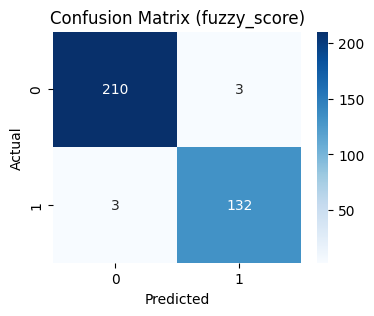

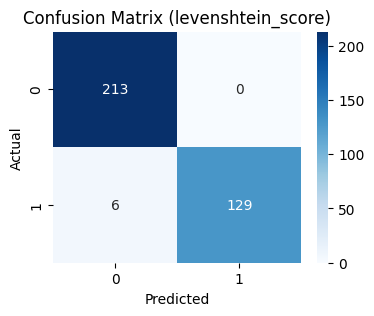

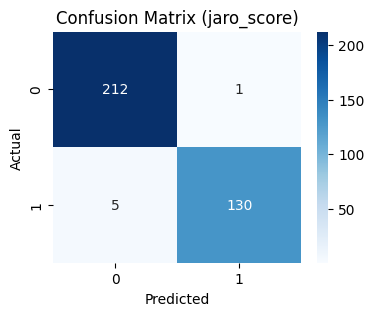

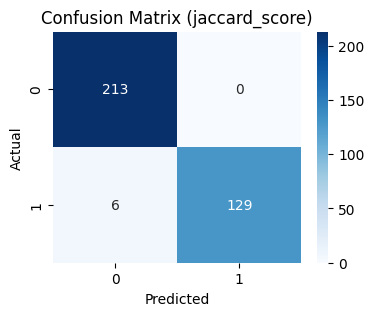

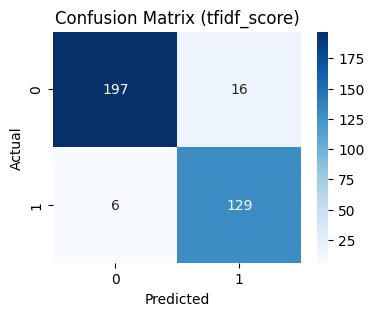

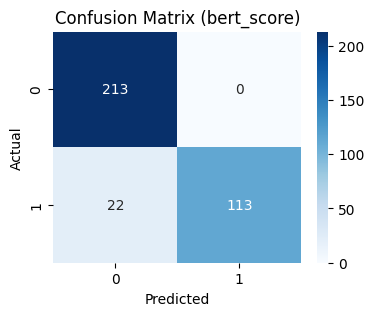

              Metric  Precision    Recall  F1-score
0        fuzzy_score   0.977778  0.977778  0.977778
1  levenshtein_score   1.000000  0.955556  0.977273
2         jaro_score   0.992366  0.962963  0.977444
3      jaccard_score   1.000000  0.955556  0.977273
4        tfidf_score   0.889655  0.955556  0.921429
5         bert_score   1.000000  0.837037  0.911290


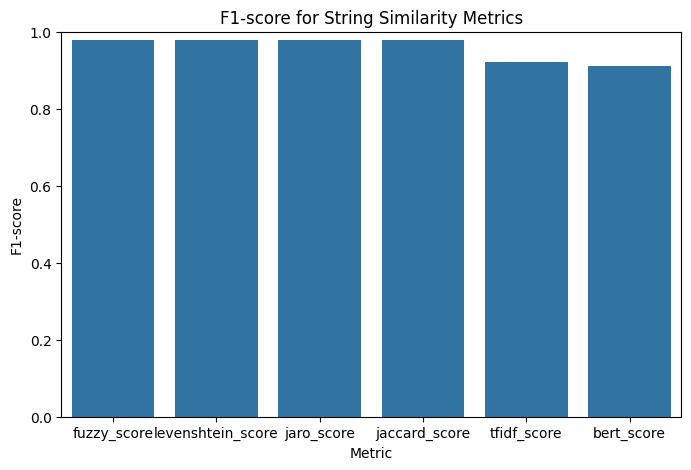

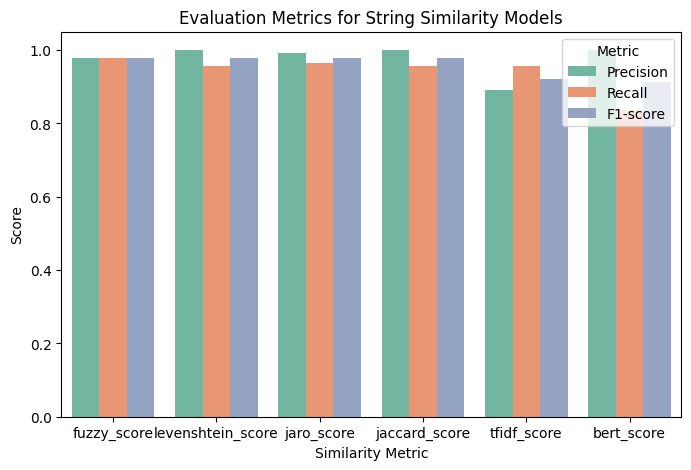

In [82]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

results = []

for metric in metrics:
    thresh = thresholds[metric]
    y_pred = (similarity_df[metric] >= thresh).astype(int)
    y_true = similarity_df['LABEL']

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    results.append({'Metric': metric, 'Precision': precision, 'Recall': recall, 'F1-score': f1})

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix ({metric})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Convert to DataFrame for barplot
results_df = pd.DataFrame(results)
print(results_df)

# Bar plot of F1-score
plt.figure(figsize=(8,5))
sns.barplot(x='Metric', y='F1-score', data=results_df)
plt.ylim(0,1)
plt.title("F1-score for String Similarity Metrics")
plt.show()

# Melt DataFrame for seaborn
df_melt = results_df.melt(id_vars='Metric', value_vars=['Precision', 'Recall', 'F1-score'],
                          var_name='Score', value_name='Value')

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x='Metric', y='Value', hue='Score', data=df_melt, palette='Set2')
plt.ylim(0,1.05)
plt.title("Evaluation Metrics for String Similarity Models")
plt.ylabel("Score")
plt.xlabel("Similarity Metric")
plt.legend(title='Metric')
plt.show()
